# 🛍️ Shopping Mall Customer Segmentation
## Notebook 0 — EDA, Data Cleaning & Preprocessing

---
### 📌 What is this notebook doing?
This notebook prepares the customer dataset before clustering.

The workflow follows this order:
1. **Load and inspect the dataset**
2. **Data cleaning**
3. **Handle missing values first**
4. **Remove duplicates**
5. **Drop useless columns**
6. **Encode categorical data**
7. **EDA**
8. **Compare clustering with and without scaling**
9. **Apply dimension reduction**
10. **Save processed data**

This version follows the updated feedback:
- data cleaning first
- missing value first
- scaling is **not forced**
- `v_measure_score` is included
- **dimension reduction** is included
- feature importance is included

---
## Step 1: Import Libraries
We load the tools needed for data cleaning, visualization, clustering, evaluation, and dimension reduction.

In [26]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.cluster import KMeans
from sklearn.metrics import v_measure_score, confusion_matrix, ConfusionMatrixDisplay
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestClassifier

import warnings
warnings.filterwarnings('ignore')

plt.style.use('default')
sns.set_theme(style='whitegrid')

---
## Step 2: Load Dataset

In [27]:
df = pd.read_csv('Shopping_Mall_Customer_Segmentation_Data_.csv')
print(f'Total customers : {len(df):,}')
print(f'Total features  : {df.shape[1]}')
print()
df.head(10)

Total customers : 15,079
Total features  : 5



,Customer ID,Age,Gender,Annual Income,Spending Score
0,d410ea53-6661-42a9-ad3a-f554b05fd2a7,30,Male,151479,89
1,1770b26f-493f-46b6-837f-4237fb5a314e,58,Female,185088,95
2,e81aa8eb-1767-4b77-87ce-1620dc732c5e,62,Female,70912,76
3,9795712a-ad19-47bf-8886-4f997d6046e3,23,Male,55460,57
4,64139426-2226-4cd6-bf09-91bce4b4db5e,24,Male,153752,76
5,7e211337-e92f-4140-8231-5c9ac7a2aa12,42,Male,158335,40
6,30661d57-eeb5-4886-970a-9c7d0f260ad8,27,Female,163501,37
7,43417ade-6b17-431e-ae76-d8ed26aa46ac,24,Male,70476,17
8,86f73b1a-6a91-4d7e-ad21-0aefcf6111cc,83,Male,47743,34
9,b20fe0a0-e254-4116-b804-5403bb2f59ea,62,Female,63448,3


---
## Step 3: Basic Dataset Overview
This section checks the structure of the raw dataset before cleaning.

In [28]:
print('--- Column Data Types ---')
df.info()
print()

print('--- Missing Values ---')
print(df.isnull().sum())
print()

print('--- Duplicate Rows ---')
print(f'Duplicates: {df.duplicated().sum()}')
print()

print('--- Statistical Summary ---')
display(df.describe(include='all').T)

--- Column Data Types ---
<class 'pandas.DataFrame'>
RangeIndex: 15079 entries, 0 to 15078
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   Customer ID     15079 non-null  str  
 1   Age             15079 non-null  int64
 2   Gender          15079 non-null  str  
 3   Annual Income   15079 non-null  int64
 4   Spending Score  15079 non-null  int64
dtypes: int64(3), str(2)
memory usage: 589.2 KB

--- Missing Values ---
Customer ID       0
Age               0
Gender            0
Annual Income     0
Spending Score    0
dtype: int64

--- Duplicate Rows ---
Duplicates: 0

--- Statistical Summary ---


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Customer ID,15079,15079,d410ea53-6661-42a9-ad3a-f554b05fd2a7,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Age,15079.0,NaN,NaN,NaN,54.191591,21.119207,18.0,36.0,54.0,72.0,90.0
Gender,15079,2,Male,7595,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Annual Income,15079.0,NaN,NaN,NaN,109742.880562,52249.425866,20022.0,64141.0,109190.0,155008.0,199974.0
Spending Score,15079.0,NaN,NaN,NaN,50.591617,28.726977,1.0,26.0,51.0,75.0,100.0


---
# PART 1 — Data Cleaning

### 📌 Why is data cleaning done first?
Clustering quality depends heavily on clean input data.

According to the updated feedback, data cleaning must be done before the rest of the analysis.
The first cleaning task is **missing value handling**.

### Step 4: Handle Missing Values First
**Purpose:** Missing values can break analysis or distort clustering results.

This step is done first as requested.

In [29]:
print('Missing values before handling:')
print(df.isnull().sum())
print()

if df.isnull().sum().sum() == 0:
    print('✅ No missing values found — no imputation needed.')
else:
    numeric_cols_fill = df.select_dtypes(include=np.number).columns
    categorical_cols_fill = df.select_dtypes(exclude=np.number).columns

    for col in numeric_cols_fill:
        df[col] = df[col].fillna(df[col].median())

    for col in categorical_cols_fill:
        if not df[col].mode().empty:
            df[col] = df[col].fillna(df[col].mode()[0])

    print('✅ Missing values handled using median (numeric) and mode (categorical).')

print()
print('Missing values after handling:')
print(df.isnull().sum())

Missing values before handling:
Customer ID       0
Age               0
Gender            0
Annual Income     0
Spending Score    0
dtype: int64

✅ No missing values found — no imputation needed.

Missing values after handling:
Customer ID       0
Age               0
Gender            0
Annual Income     0
Spending Score    0
dtype: int64


### Step 5: Remove Duplicate Rows
**Purpose:** Duplicate records may bias the cluster centers.

In [30]:
before_rows = len(df)
df = df.drop_duplicates()
after_rows = len(df)

print(f'Rows before duplicate removal : {before_rows:,}')
print(f'Rows after duplicate removal  : {after_rows:,}')
print(f'✅ Duplicates removed          : {before_rows - after_rows:,}')

Rows before duplicate removal : 15,079
Rows after duplicate removal  : 15,079
✅ Duplicates removed          : 0


### Step 6: Drop Useless Columns
**Purpose:** Unique IDs do not provide useful grouping information for clustering.

In [31]:
df_clean = df.copy()

id_candidates = ['Customer ID', 'CustomerID', 'customer_id', 'ID', 'Id']
drop_cols = [col for col in id_candidates if col in df_clean.columns]

if drop_cols:
    df_clean = df_clean.drop(columns=drop_cols)
    print(f'✅ Dropped useless column(s): {drop_cols}')
else:
    print('ℹ️ No ID column found to drop.')

print()
print('Remaining columns:', list(df_clean.columns))
display(df_clean.head())

✅ Dropped useless column(s): ['Customer ID']

Remaining columns: ['Age', 'Gender', 'Annual Income', 'Spending Score']


,Age,Gender,Annual Income,Spending Score
0,30,Male,151479,89
1,58,Female,185088,95
2,62,Female,70912,76
3,23,Male,55460,57
4,24,Male,153752,76


### Step 7: Encode Categorical Data
**Purpose:** Clustering algorithms require numeric input.

`Gender` is converted from text into numbers.

In [32]:
encoders = {}

for col in df_clean.select_dtypes(include='object').columns:
    le = LabelEncoder()
    df_clean[col] = le.fit_transform(df_clean[col])
    encoders[col] = dict(zip(le.classes_, le.transform(le.classes_)))

if encoders:
    print('✅ Encoded categorical columns:')
    for col, mapping in encoders.items():
        print(f'   {col}: {mapping}')
else:
    print('ℹ️ No categorical columns found.')

print()
display(df_clean.head())

✅ Encoded categorical columns:
   Gender: {'Female': np.int64(0), 'Male': np.int64(1)}



,Age,Gender,Annual Income,Spending Score
0,30,1,151479,89
1,58,0,185088,95
2,62,0,70912,76
3,23,1,55460,57
4,24,1,153752,76


---
# PART 2 — EDA (Exploratory Data Analysis)

### 📌 Why do we still do EDA after cleaning?
Now that the dataset is clean, we can inspect the distributions and relationships more accurately.

### Plot 1: Feature Distributions
**Purpose:** Understand how each numeric feature is distributed.

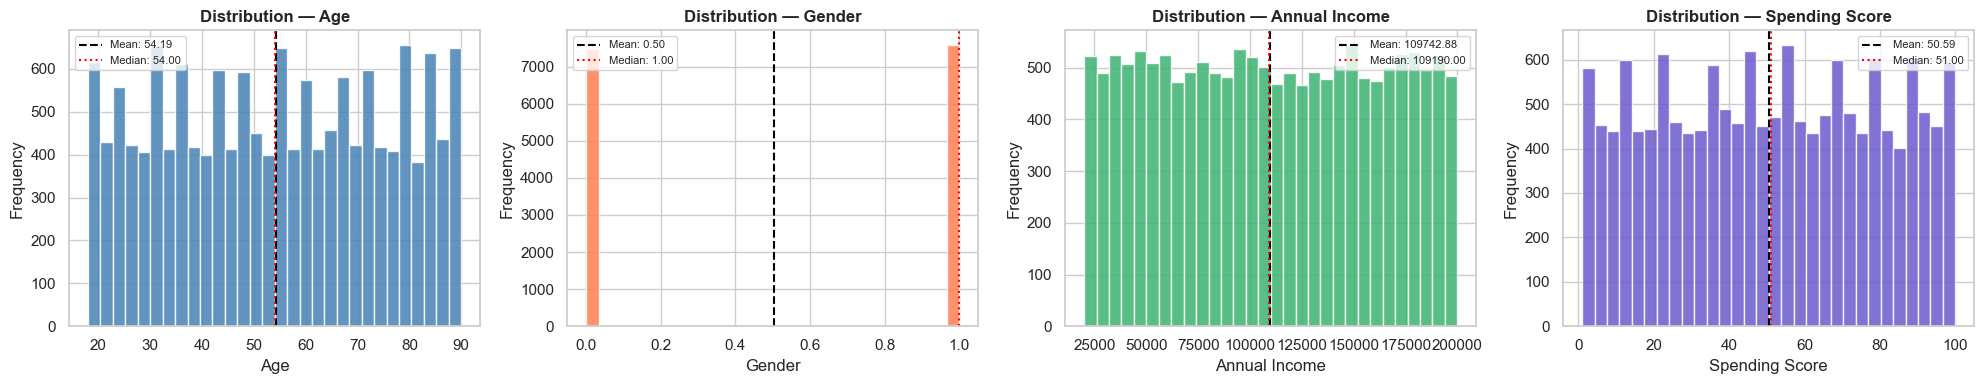

In [33]:
numeric_cols = df_clean.select_dtypes(include=np.number).columns.tolist()
plot_colors = ['steelblue', 'coral', 'mediumseagreen', 'slateblue', 'goldenrod']

fig, axes = plt.subplots(1, len(numeric_cols), figsize=(5 * len(numeric_cols), 4))

if len(numeric_cols) == 1:
    axes = [axes]

for ax, col, color in zip(axes, numeric_cols, plot_colors * 5):
    ax.hist(df_clean[col], bins=30, color=color, edgecolor='white', alpha=0.85)
    ax.axvline(df_clean[col].mean(), color='black', linestyle='--', linewidth=1.5, label=f'Mean: {df_clean[col].mean():.2f}')
    ax.axvline(df_clean[col].median(), color='red', linestyle=':', linewidth=1.5, label=f'Median: {df_clean[col].median():.2f}')
    ax.set_title(f'Distribution — {col}', fontweight='bold')
    ax.set_xlabel(col)
    ax.set_ylabel('Frequency')
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

### Plot 2: Box Plots — Outlier Detection
**Purpose:** Detect extreme values that may influence clustering.

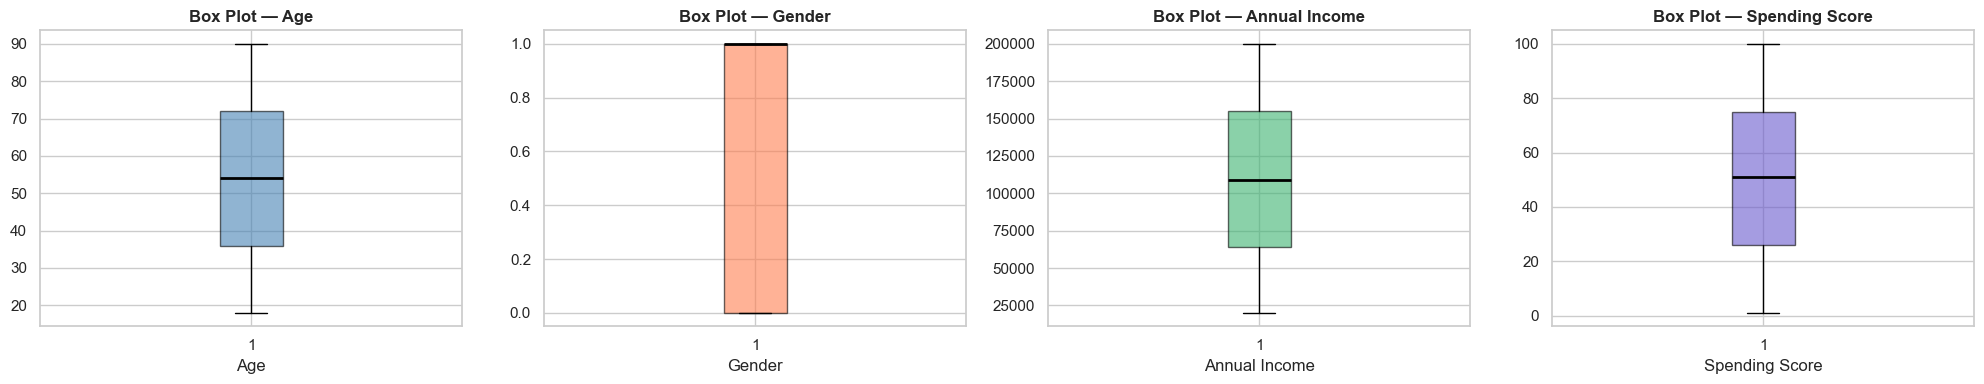

In [34]:
fig, axes = plt.subplots(1, len(numeric_cols), figsize=(5 * len(numeric_cols), 4))

if len(numeric_cols) == 1:
    axes = [axes]

for ax, col, color in zip(axes, numeric_cols, plot_colors * 5):
    ax.boxplot(
        df_clean[col],
        patch_artist=True,
        boxprops=dict(facecolor=color, alpha=0.6),
        medianprops=dict(color='black', linewidth=2),
        flierprops=dict(marker='o', markersize=4, alpha=0.35)
    )
    ax.set_title(f'Box Plot — {col}', fontweight='bold')
    ax.set_xlabel(col)

plt.tight_layout()
plt.show()

### Plot 3: Scatter Plots — Pre-clustering Visual
**Purpose:** Check whether natural groups may already exist before clustering.

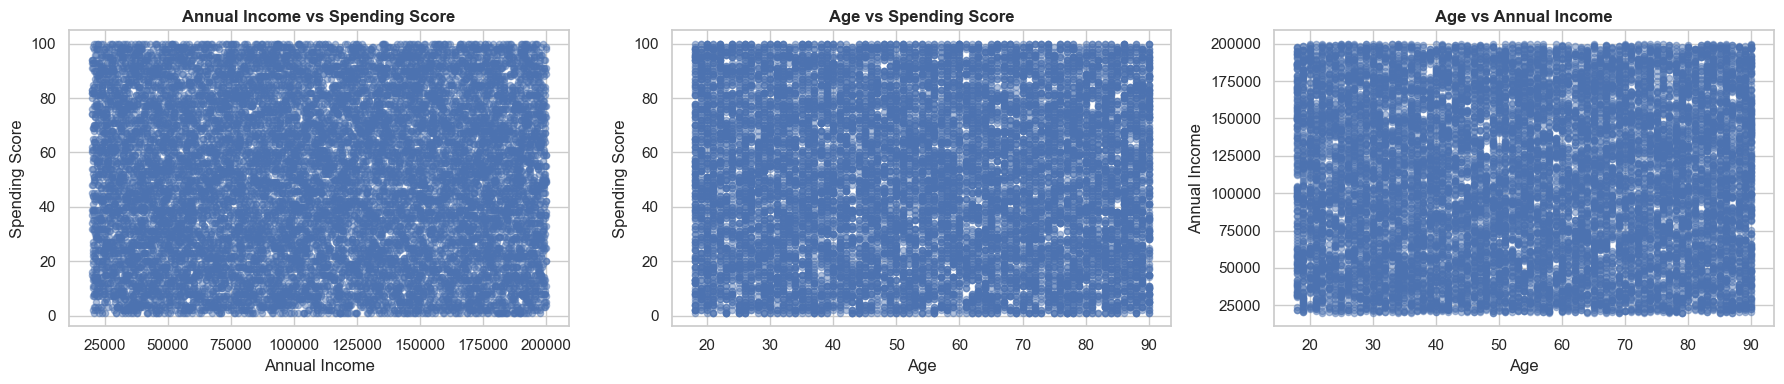

In [35]:
candidate_pairs = []
if 'Annual Income' in df_clean.columns and 'Spending Score' in df_clean.columns:
    candidate_pairs.append(('Annual Income', 'Spending Score'))
if 'Age' in df_clean.columns and 'Spending Score' in df_clean.columns:
    candidate_pairs.append(('Age', 'Spending Score'))
if 'Age' in df_clean.columns and 'Annual Income' in df_clean.columns:
    candidate_pairs.append(('Age', 'Annual Income'))

if candidate_pairs:
    fig, axes = plt.subplots(1, len(candidate_pairs), figsize=(6 * len(candidate_pairs), 4))
    if len(candidate_pairs) == 1:
        axes = [axes]

    for ax, (x_col, y_col) in zip(axes, candidate_pairs):
        ax.scatter(df_clean[x_col], df_clean[y_col], alpha=0.45, s=20)
        ax.set_title(f'{x_col} vs {y_col}', fontweight='bold')
        ax.set_xlabel(x_col)
        ax.set_ylabel(y_col)

    plt.tight_layout()
    plt.show()
else:
    print('Not enough matching columns for the expected scatter plots.')

### Plot 4: Correlation Matrix
**Purpose:** Identify whether features are highly related to each other.

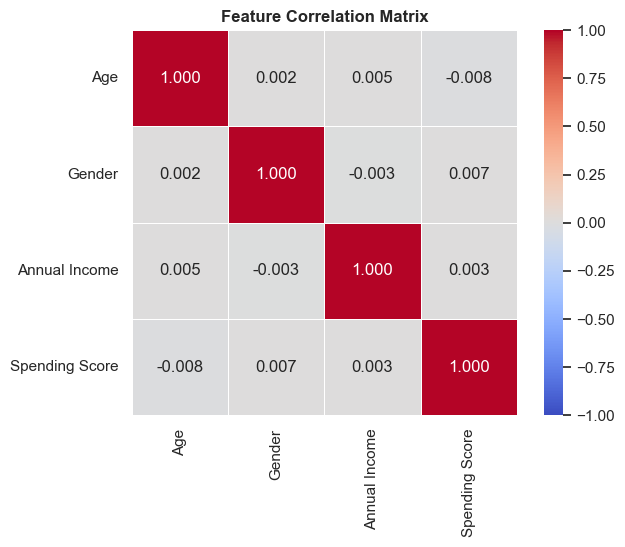

In [36]:
corr_matrix = df_clean[numeric_cols].corr()

plt.figure(figsize=(7, 5))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt='.3f',
    cmap='coolwarm',
    linewidths=0.5,
    vmin=-1,
    vmax=1,
    square=True
)
plt.title('Feature Correlation Matrix', fontweight='bold')
plt.show()

### Plot 5: Pairplot
**Purpose:** Visualize pairwise relationships in the cleaned dataset.

This keeps the notebook style close to the earlier version.

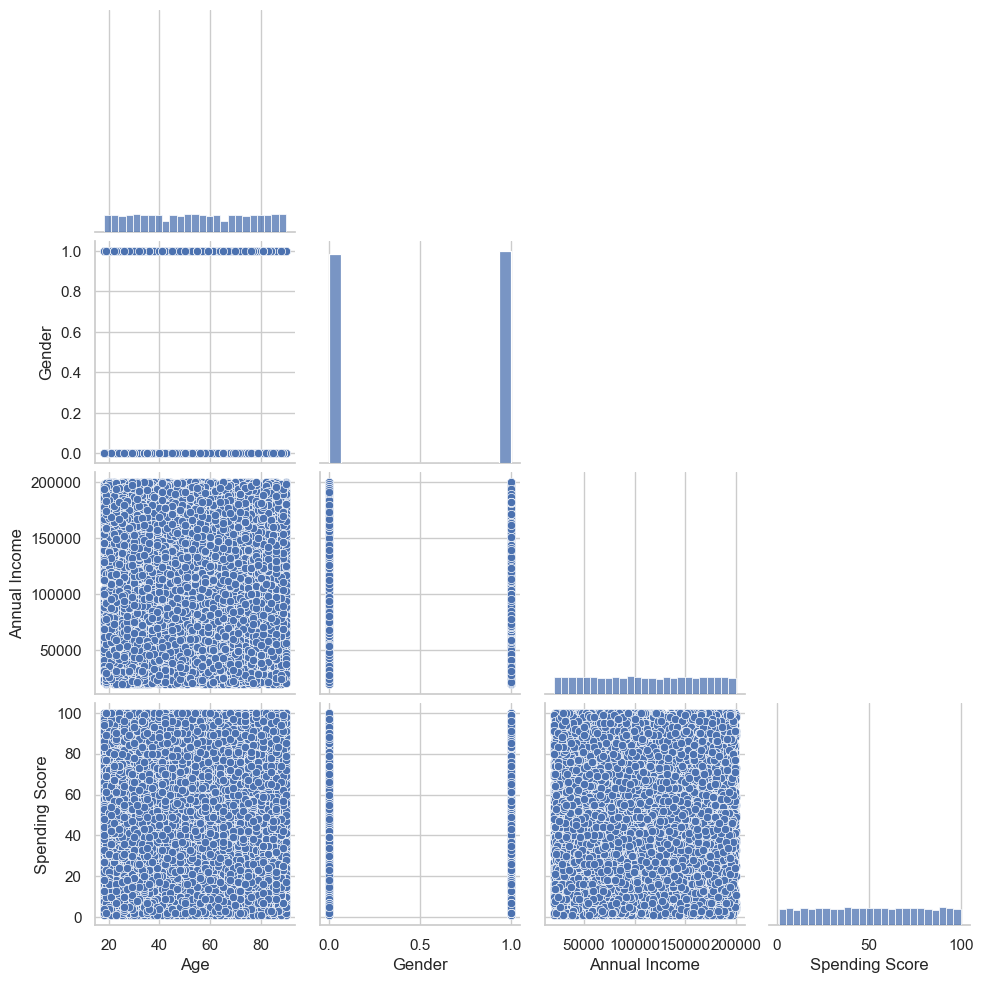

In [ ]:
pairplot_df = df_clean.copy()

# limit very wide pairplots if many columns exist
pairplot_cols = numeric_cols[:5]
sns.pairplot(pairplot_df[pairplot_cols], diag_kind='hist')
plt.show()

---
# PART 3 — Scaling Comparison

### 📌 Why compare scaling instead of forcing it?
Based on the feedback, scaling may or may not be needed.

So this notebook compares:
- clustering without scaling
- clustering with scaling

Then it uses `v_measure_score` as an external comparison reference.

### Step 8: Prepare Feature Matrix

In [38]:
X = df_clean.copy()
print('Feature matrix shape:', X.shape)
display(X.head())

Feature matrix shape: (15079, 4)


,Age,Gender,Annual Income,Spending Score
0,30,1,151479,89
1,58,0,185088,95
2,62,0,70912,76
3,23,1,55460,57
4,24,1,153752,76


### Step 9: K-Means Without Scaling

In [39]:
kmeans_raw = KMeans(n_clusters=5, random_state=42, n_init=10)
labels_raw = kmeans_raw.fit_predict(X)

print('✅ K-Means completed without scaling.')
print('Cluster counts (raw):')
print(pd.Series(labels_raw).value_counts().sort_index())

✅ K-Means completed without scaling.
Cluster counts (raw):
0    2983
1    3000
2    3138
3    2930
4    3028
Name: count, dtype: int64


### Step 10: K-Means With Scaling

In [40]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

kmeans_scaled = KMeans(n_clusters=5, random_state=42, n_init=10)
labels_scaled = kmeans_scaled.fit_predict(X_scaled)

print('✅ K-Means completed with scaling.')
print('Cluster counts (scaled):')
print(pd.Series(labels_scaled).value_counts().sort_index())

✅ K-Means completed with scaling.
Cluster counts (scaled):
0    3755
1    2394
2    2314
3    2799
4    3817
Name: count, dtype: int64


### Step 11: Compare Using V-measure Score
**Purpose:** Use an external reference to compare clustering alignment.

If `Gender` exists, it is used as the external comparison label.
This does **not** mean Gender is the true cluster label.
It is only used as a reference for evaluation.

In [41]:
if 'Gender' in X.columns:
    score_raw = v_measure_score(X['Gender'], labels_raw)
    score_scaled = v_measure_score(X['Gender'], labels_scaled)

    print(f'V-measure (No Scaling)  : {score_raw:.4f}')
    print(f'V-measure (With Scaling): {score_scaled:.4f}')

    if score_scaled >= score_raw:
        chosen_version = 'scaled'
        final_labels = labels_scaled
        final_X_for_model = X_scaled
    else:
        chosen_version = 'raw'
        final_labels = labels_raw
        final_X_for_model = X.values

    print()
    print(f'✅ Selected version based on V-measure: {chosen_version}')
else:
    score_raw = None
    score_scaled = None
    chosen_version = 'scaled'
    final_labels = labels_scaled
    final_X_for_model = X_scaled
    print('ℹ️ Gender column not found. Defaulting to scaled version.')

V-measure (No Scaling)  : 0.0002
V-measure (With Scaling): 0.5997

✅ Selected version based on V-measure: scaled


### Plot 6: Compare Clusters Before and After Scaling

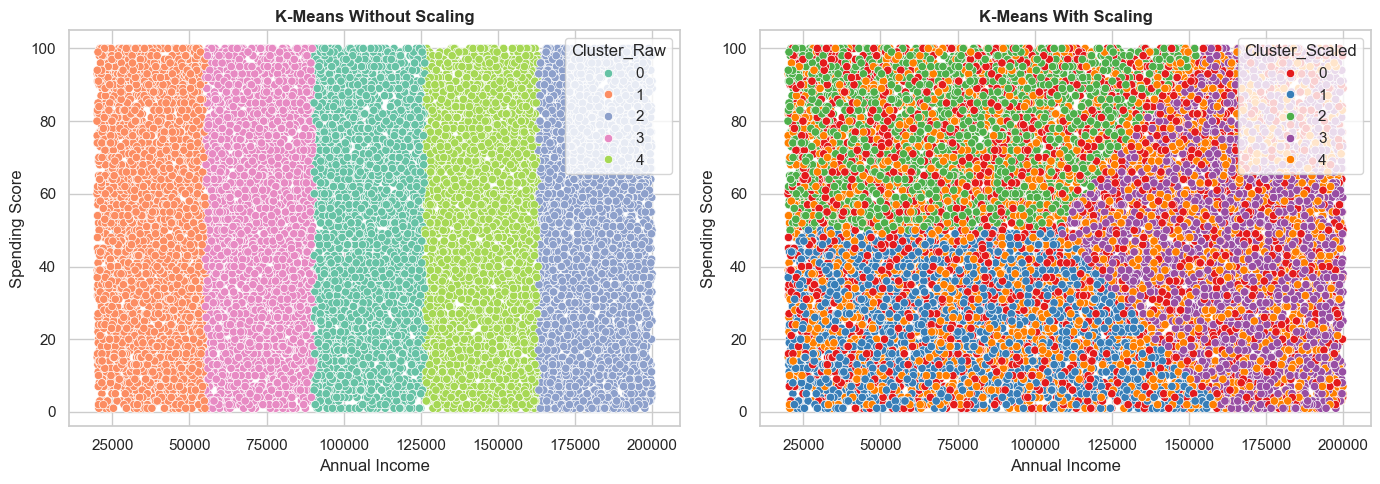

In [42]:
compare_df = df_clean.copy()
compare_df['Cluster_Raw'] = labels_raw
compare_df['Cluster_Scaled'] = labels_scaled

if 'Annual Income' in compare_df.columns and 'Spending Score' in compare_df.columns:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    sns.scatterplot(
        data=compare_df,
        x='Annual Income',
        y='Spending Score',
        hue='Cluster_Raw',
        palette='Set2',
        ax=axes[0]
    )
    axes[0].set_title('K-Means Without Scaling', fontweight='bold')

    sns.scatterplot(
        data=compare_df,
        x='Annual Income',
        y='Spending Score',
        hue='Cluster_Scaled',
        palette='Set1',
        ax=axes[1]
    )
    axes[1].set_title('K-Means With Scaling', fontweight='bold')

    plt.tight_layout()
    plt.show()
else:
    print('Expected columns for comparison plot are not available.')

---
# PART 4 — Dimension Reduction

### 📌 Why do dimension reduction?
Dimension reduction simplifies the feature space while preserving important information.

Here, **PCA (Principal Component Analysis)** is used to reduce the data into 2 dimensions for easier visualization.

### Step 12: Apply PCA

In [43]:
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(final_X_for_model)

df_result = df_clean.copy()
df_result['Cluster'] = final_labels
df_result['PCA1'] = X_pca[:, 0]
df_result['PCA2'] = X_pca[:, 1]

print('Explained variance ratio:')
for i, ratio in enumerate(pca.explained_variance_ratio_, start=1):
    print(f'PC{i}: {ratio:.4f}')

print(f'Total explained variance by 2 components: {pca.explained_variance_ratio_.sum():.4f}')

display(df_result.head())

Explained variance ratio:
PC1: 0.2525
PC2: 0.2507
Total explained variance by 2 components: 0.5032


,Age,Gender,Annual Income,Spending Score,Cluster,PCA1,PCA2
0,30,1,151479,89,0,1.842437,0.907756
1,58,0,185088,95,3,0.309345,1.362407
2,62,0,70912,76,2,0.123684,-0.421931
3,23,1,55460,57,0,1.583000,-1.009438
4,24,1,153752,76,0,1.685435,0.652765


### Plot 7: PCA Cluster Visualization
**Purpose:** Visualize cluster separation in 2D after dimension reduction.

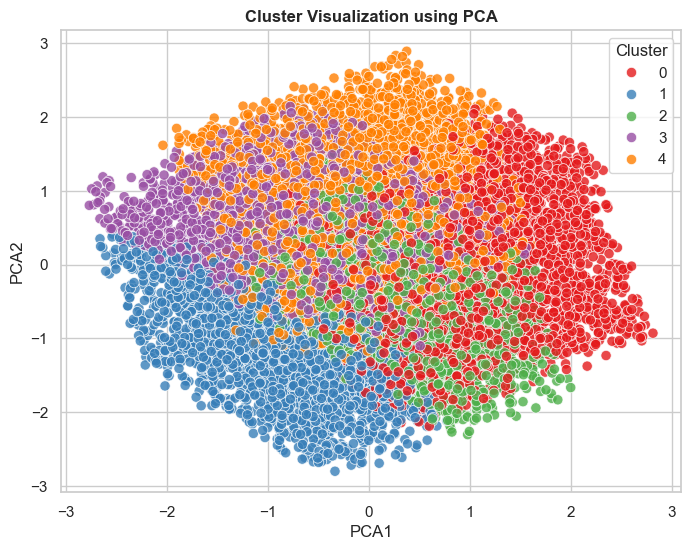

In [44]:
plt.figure(figsize=(8, 6))
sns.scatterplot(
    data=df_result,
    x='PCA1',
    y='PCA2',
    hue='Cluster',
    palette='Set1',
    s=55,
    alpha=0.8
)
plt.title('Cluster Visualization using PCA', fontweight='bold')
plt.show()

### Step 13: PCA Loading Matrix
**Purpose:** Show how original features contribute to the principal components.

In [48]:
loading_matrix = pd.DataFrame(
    pca.components_.T,
    index=X.columns,
    columns=['PC1', 'PC2']
)

display(loading_matrix.style.background_gradient(cmap='coolwarm'))

,PC1,PC2
Age,-0.575071,0.443172
Gender,0.401498,0.343960
Annual Income,-0.174096,0.746875
Spending Score,0.691218,0.357027


---
# PART 5 — Optional External Evaluation

### 📌 Why is confusion matrix optional?
This is still an **unsupervised learning** task.

So the confusion matrix is not the main evaluation tool.
It is shown only as an external comparison against Gender if needed.

### Step 14: Optional Confusion Matrix

<Figure size 700x500 with 0 Axes>

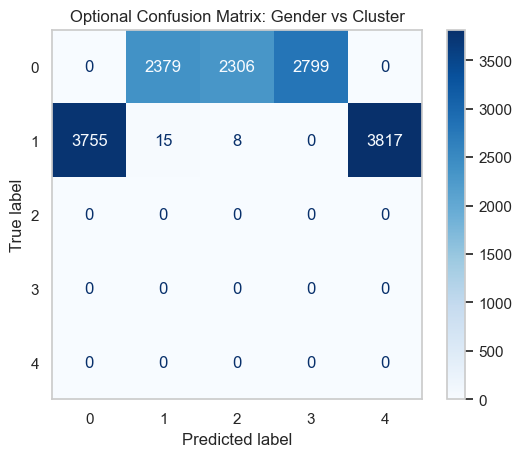

In [46]:
if 'Gender' in X.columns:
    cm = confusion_matrix(X['Gender'], final_labels)

    plt.figure(figsize=(7, 5))
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot(cmap='Blues', values_format='d')
    plt.title('Optional Confusion Matrix: Gender vs Cluster')
    plt.grid(False)
    plt.show()
else:
    print('Gender column not found. Confusion matrix skipped.')

---
# PART 6 — Feature Importance

### 📌 Why use feature importance here?
K-Means does not directly provide feature importance.

So a Random Forest model is trained to predict the cluster labels, then the feature importance scores are used to explain which features most influence the clusters.

### Step 15: Feature Importance

Feature Importance:


,Importance
Gender,0.344454
Age,0.256118
Annual Income,0.207023
Spending Score,0.192405


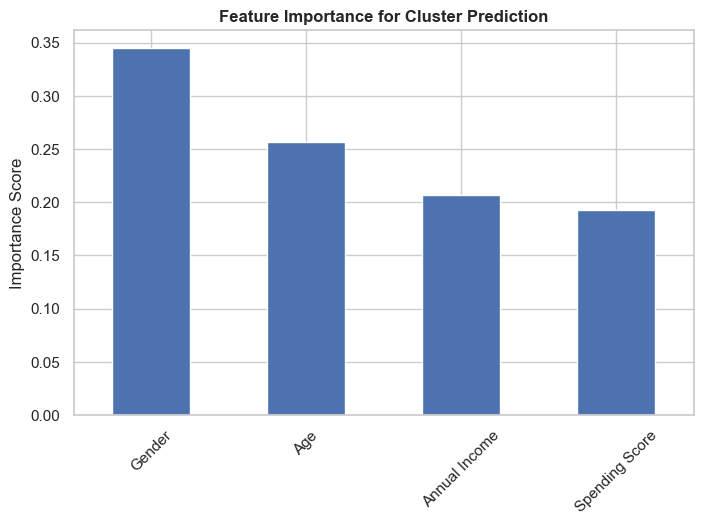

In [47]:
rf = RandomForestClassifier(random_state=42)
rf.fit(X, final_labels)

feature_importance = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False)

print('Feature Importance:')
display(feature_importance.to_frame(name='Importance'))

plt.figure(figsize=(8, 5))
feature_importance.plot(kind='bar')
plt.title('Feature Importance for Cluster Prediction', fontweight='bold')
plt.ylabel('Importance Score')
plt.xticks(rotation=45)
plt.show()

---
# PART 7 — Cluster Profile

### Step 16: Cluster Mean Profile
This helps interpret the characteristics of each cluster.

In [ ]:
cluster_profile = df_result.groupby('Cluster')[X.columns.tolist()].mean().round(2)
display(cluster_profile)

,Age,Gender,Annual Income,Spending Score
Cluster,,,,
0,35.74,1.00,107946.38,52.56
1,53.81,0.01,77705.71,23.47
2,54.60,0.00,75691.77,77.24
3,54.07,0.00,165066.98,51.13
4,72.42,1.00,111677.63,49.12


### Plot 8: Cluster Profile Heatmap

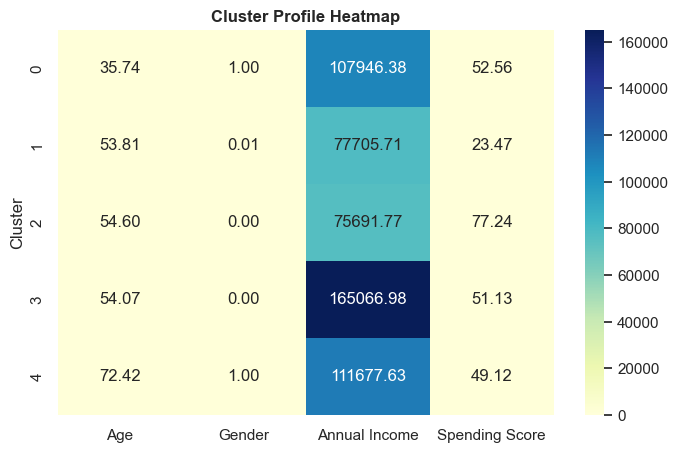

In [ ]:
plt.figure(figsize=(8, 5))
sns.heatmap(cluster_profile, annot=True, fmt='.2f', cmap='YlGnBu')
plt.title('Cluster Profile Heatmap', fontweight='bold')
plt.show()

---
# PART 8 — Save Processed Data

### Step 17: Save Files
We save the main outputs for later notebooks or reports.

In [ ]:
df_clean.to_csv('data_cleaned.csv', index=False)
df_result.to_csv('data_with_clusters_pca.csv', index=False)
np.save('X_scaled.npy', X_scaled)
np.save('X_pca.npy', X_pca)

print('✅ Saved: data_cleaned.csv')
print('✅ Saved: data_with_clusters_pca.csv')
print('✅ Saved: X_scaled.npy')
print('✅ Saved: X_pca.npy')

✅ Saved: data_cleaned.csv
✅ Saved: data_with_clusters_pca.csv
✅ Saved: X_scaled.npy
✅ Saved: X_pca.npy


---
## Summary

| Step | Action | Result |
|------|--------|--------|
| Missing value handling | Done first | Required by feedback |
| Duplicate removal | Done | Prevent repeated bias |
| ID removal | Done | Useless for clustering |
| Encoding | Done | Convert categorical data to numeric |
| EDA | Done | Understand distributions and relationships |
| Scaling comparison | Done | Compare with and without scaling |
| V-measure score | Done | External evaluation reference |
| Dimension reduction | Done | PCA added |
| Feature importance | Done | Explain cluster-driving features |
| Saved output files | Done | Ready for next stage |